In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/minahilfatima12328/consumer-shopping-trends-analysis/Consumer_Shopping_Trends_2026 (6).csv


                  Feature  Importance
10        avg_store_spend    0.562560
18  need_touch_feel_score    0.043722
6        tech_savvy_score    0.032861
7   monthly_online_orders    0.032461
2    daily_internet_hours    0.028732
8    monthly_store_visits    0.027390
9        avg_online_spend    0.024132
1          monthly_income    0.023331
4      social_media_hours    0.020949
0                     age    0.020076


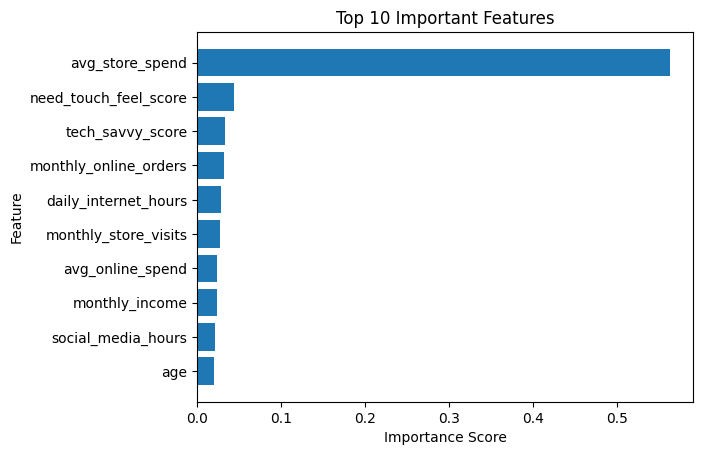

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load dataset
df = pd.read_csv('/kaggle/input/datasets/minahilfatima12328/consumer-shopping-trends-analysis/Consumer_Shopping_Trends_2026 (6).csv')

# Clean column names
df.columns = df.columns.str.strip()
df = df.dropna()

# Target
target = 'shopping_preference'

# Split features and target
X = df.drop(columns=[target])
y = df[target]

# Encode categorical variables
X = pd.get_dummies(X, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Feature importance
importances = model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
})

# Sort descending
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Take top 10
top_features = feature_importance_df.head(10)

print(top_features)

# Save table
top_features.to_csv('/kaggle/working/RQ4_table.csv', index=False)

# Plot
plt.figure()
plt.barh(top_features['Feature'], top_features['Importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')

# Save figure
plt.savefig('/kaggle/working/RQ4_figure.pdf')
plt.show()